In [1]:
import os

#add the root directory
os.chdir('../')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from loader import *
import h5py
import matplotlib.ticker as ticker
import matplotlib.transforms as transforms
import matplotlib.lines as mlines
from PCAfold import normalized_variance_derivative, cost_function_normalized_variance_derivative
import re
from matplotlib import gridspec
import matplotlib.cm as cm
from matplotlib.lines import Line2D

from os import listdir
from os.path import isfile, join
from scipy.io import loadmat
from tools import *
import logging
from utils import *

logging.disable(logging.CRITICAL) #disable the logging

# Figure 10: Heuristic vs optimized for the flamelet dataset

In [3]:
path_variance = "data-files/costs/"

name_heuristic = "variance_Xu-bw_-6_2_100-dataset_flamelet-Yuki-v2.npy"
name_heuristicSoph1000HO2 = "variance_heuSophHO21000-bw_-6_2_100-dataset_flamelet-Yuki-v2.npy"
name_heuristicSoph1000NO = "variance_heuSophNO1000-bw_-6_2_100-dataset_flamelet-Yuki-v2.npy"
name_Optimized = "variance_Tr35a_Yuki_v2_linLog_R1_s8-bw_-6_2_100-dataset_flamelet-Yuki-v2.npy"

penalty_function = 'log-sigma-over-peak'
power = 4
vertical_shift = 1

variance_heuristic = np.load(f"{path_variance}{name_heuristic}", allow_pickle=True).item()
variance_heuristicSoph1000HO2 = np.load(f"{path_variance}{name_heuristicSoph1000HO2}", allow_pickle=True).item()
variance_heuristicSoph1000NO = np.load(f"{path_variance}{name_heuristicSoph1000NO}", allow_pickle=True).item()
variance_Optimized = np.load(f"{path_variance}{name_Optimized}", allow_pickle=True).item()

(derivative_heuristic, bandwidth_values_heuristic, max_derivative_heuristic) = normalized_variance_derivative(variance_heuristic)
(derivative_heuristicSoph10HO2, bandwidth_values_heuristicSoph10HO2, max_derivative_heuristicSoph10HO2) = normalized_variance_derivative(variance_heuristicSoph1000HO2)
(derivative_heuristicSoph1NO, bandwidth_values_heuristicSoph1NO, max_derivative_heuristicSoph1NO) = normalized_variance_derivative(variance_heuristicSoph1000NO)
(derivative_Optimized, bandwidth_values_Optimized, max_derivative_Optimized) = normalized_variance_derivative(variance_Optimized)

keys = ['H2O2', 'H2O', 'H2', 'HO2', 'N2O', 'NO2', 'NO', 'O2', 'OH', 'T', 'PV1']

costsheuristic = cost_function_normalized_variance_derivative(variance_heuristic,
                                                            penalty_function=penalty_function,
                                                            power=power,
                                                            vertical_shift=vertical_shift,
                                                            norm=None)
costsHeuristicSoph1000HO2 = cost_function_normalized_variance_derivative(variance_heuristicSoph1000HO2,
                                                            penalty_function=penalty_function,
                                                            power=power,
                                                            vertical_shift=vertical_shift,
                                                            norm=None)
costsHeuristicSoph1000NO = cost_function_normalized_variance_derivative(variance_heuristicSoph1000NO,
                                                            penalty_function=penalty_function,
                                                            power=power,
                                                            vertical_shift=vertical_shift,
                                                            norm=None)
costsOptimized = cost_function_normalized_variance_derivative(variance_Optimized,
                                                            penalty_function=penalty_function,
                                                            power=power,
                                                            vertical_shift=vertical_shift,
                                                            norm=None)

MSEheuristic = np.load("paper/data/MSE_QoIs_val_NN_heuristic_flamelet-Yuki-v2_s7_epo500_lr0.01_scaleManifoldFalse_epoDecay500.npy")
MSEheuristicSoph1000HO2 = np.load("paper/data/MSE_QoIs_val_NN_heuristicSoph1000HO2_flamelet-Yuki-v2_s7_epo500_lr0.01_scaleManifoldFalse.npy")
MSEheuristicSoph1000NO = np.load("paper/data/MSE_QoIs_val_NN_heuristicSoph1000NO_flamelet-Yuki-v2_s7_epo500_lr0.01_scaleManifoldFalse.npy")
MSEOptimized = np.load("paper/data/MSE_QoIs_val_NN_Tr35a_Yuki_v2_linLog_R1_s8_flamelet-Yuki-v2_s7_epo500_lr0.01_scaleManifoldFalse.npy")

In [4]:
path_data = "data-files/"
filename_prefix = "Xu"
filename_suffix = "flamelet-Yuki-v2-augm"

mf_fl = pd.read_csv(path_data + f"{filename_prefix}-mf-{filename_suffix}.csv")
T_fl = pd.read_csv(path_data + f"{filename_prefix}-T-{filename_suffix}.csv")
x_fl = pd.read_csv(path_data + f"{filename_prefix}-state-space-{filename_suffix}.csv")
Sx_fl = pd.read_csv(path_data + f"{filename_prefix}-state-space_source-{filename_suffix}.csv")

PV_heuristic = x_fl["H2O"] - x_fl["H2"] - x_fl["O2"]
PV_heuristic_source = Sx_fl["H2O"] - Sx_fl["H2"] - Sx_fl["O2"]

filename = "Xu-AE-opt_RMSprop-epo_100000-lr_0.025-date_07Apr2026-hour_16h39_Tr35a_Yuki_v2_linLog_R1_s8"

filename_metadata = filename + "_metadata.pkl"
filename_species_names = "Xu-state-space-names-flamelet-Yuki-v2.csv"
path_metadata = "C:/Users/admin/Documents/PhD-ULB/Programming/2024-PV-optimization-Xu/metadata/"

loader = loadData(filename_species_names, path_metadata, filename_metadata)
output_idx = loader.metadata["output species idx"]
idx_species_removed = loader.metadata["list idx species removed source"] if 'augm' in loader.metadata["dataset_type"] else loader.metadata["idx species removed"]
input_scaling = loader.metadata["input scaling"]
input_species_scaling = loader.metadata["input species scaling"]
input_species_bias = loader.metadata["input species bias"]
range_mf  = loader.metadata["range_mf"]
id_model = loader.metadata["Training_id"]

model_reloaded = loader.loadModel()

#code not completely correct as the input dataset contains also the log species, but code written as such that it uses the correct columns
dataset = "flamelet-Yuki-v2-augm"
input_fl, output_fl = get_dataset(path_data + f"Xu-state-space-{dataset}.csv", path_data + f"Xu-state-space_source-{dataset}.csv",
                                  path_data + f"Xu-T-{dataset}.csv", path_data + f"Xu-mf-{dataset}.csv", output_idx, idx_species_removed,
                                  input_scaling, input_species_scaling, input_species_bias, range_mf)
_, PV_optimized, PV_optimized_source = model_reloaded.get_mf_PV_PVsource(input_fl, output_fl)

In [6]:
keys = ['H2O2', 'H2O', 'H2', 'HO2', 'N2O', 'NO2', 'NO', 'O2', 'OH', 'T', '$\dot{\omega}_{\mathrm{PV}}$']
keys = [k.replace("2", "$_2$") for k in keys]

greys = cm.get_cmap('Greys')

# Convert to numpy arrays
MSE_heuristic = np.array(MSEheuristic)
MSE_Optimized    = np.array(MSEOptimized)
Cost_heuristic = np.array(costsheuristic)
Cost_Optimized    = np.array(costsOptimized)
features = np.array(keys)

# Compute difference in MSE (absolute change)
delta_MSE = np.abs(np.log(MSE_Optimized) - np.log(MSE_heuristic))

# Sort features by delta_MSE (largest first)
order = np.argsort(delta_MSE)

# Reorder all arrays
features_sorted = features[order]
MSE_heuristic_sorted = MSE_heuristic[order]
MSE_Optimized_sorted = MSE_Optimized[order]
Cost_heuristic_sorted = Cost_heuristic[order]
Cost_Optimized_sorted = Cost_Optimized[order]

# Sub-line vertical offsets
subline_offset = 0.15

C:\Windows\Temp\ipykernel_1472\1295798427.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  greys = cm.get_cmap('Greys')


C:\Windows\Temp\ipykernel_8904\1114282805.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  greys = cm.get_cmap('Greys')
C:\Windows\Temp\ipykernel_8904\1114282805.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


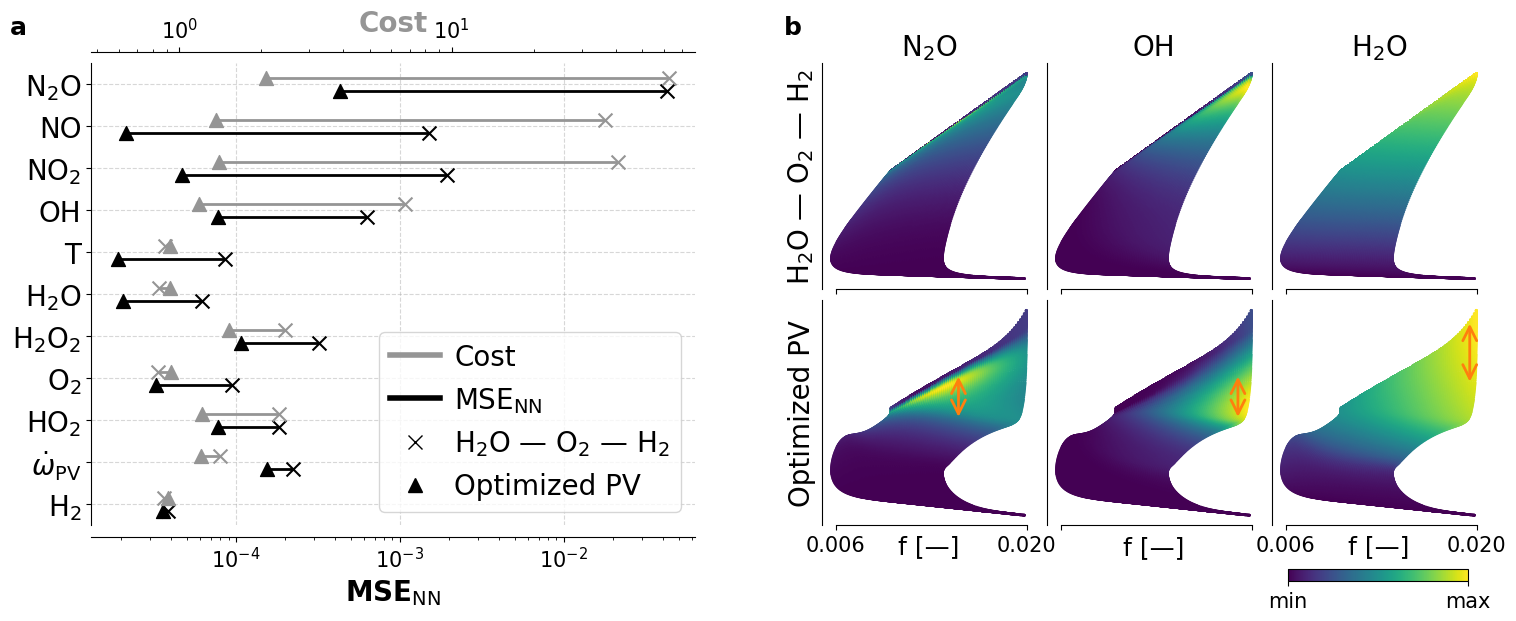

In [44]:
save = True
pathSave = f"C:/Users/Admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/"
nameSave = f"Figure 10 - flamelet Yuki - heuristic vs. optimized PV"

def add_panel_label(ax, label, x_offset=-0.12, y_offset=1.08, fontsize=18):
    ax.text(
        x_offset, y_offset,
        label,
        transform=ax.transAxes,
        fontsize=fontsize,
        fontweight="bold",
        va="top",
        ha="left",
        clip_on=False
    )

def plot_left_panel(ax_mse):
    greys = cm.get_cmap('Greys')

    ax_cost = ax_mse.twiny()

    for i, feature in enumerate(features_sorted):
        y_center = i

        # --- MSE ---
        y = y_center - subline_offset
        ax_mse.plot([MSE_heuristic_sorted[i], MSE_Optimized_sorted[i]], [y, y],
                    color="k", linewidth=2)
        ax_mse.scatter(MSE_heuristic_sorted[i], y, color="k", marker="x", s=100, zorder=4)
        ax_mse.scatter(MSE_Optimized_sorted[i], y, color="k", marker="^", s=100, zorder=5)

        # --- Cost ---
        y = y_center + subline_offset
        ax_cost.plot([Cost_heuristic_sorted[i], Cost_Optimized_sorted[i]], [y, y],
                     color=greys(0.5), linewidth=2)
        ax_cost.scatter(Cost_heuristic_sorted[i], y, color=greys(0.5), marker="x", s=100)
        ax_cost.scatter(Cost_Optimized_sorted[i], y, color=greys(0.5), marker="^", s=100)

    ax_mse.set_yticks(range(len(features_sorted)))
    ax_mse.set_yticklabels(features_sorted, fontsize=20)

    ax_mse.set_xlabel("MSE$_{\mathrm{NN}}$", fontsize=20, fontweight="bold")
    ax_cost.set_xlabel("Cost", fontsize=20, color=greys(0.5),
                       labelpad=-10, fontweight="bold")

    ax_mse.set_xscale("log")
    ax_cost.set_xscale("log")

    ax_mse.grid(axis='both', linestyle='--', alpha=0.5)
    ax_mse.tick_params(axis="x", labelsize=15)
    ax_cost.tick_params(axis="x", labelsize=15)

    ax_mse.set_ylim(-0.5, len(features_sorted) - 0.5)

    # Spines
    ax_mse.spines['top'].set_visible(False)
    ax_mse.spines['right'].set_visible(False)
    ax_cost.spines['right'].set_visible(False)
    ax_cost.spines['left'].set_visible(False)
    ax_cost.spines['bottom'].set_visible(False)

    xmin, xmax = ax_cost.get_xlim()
    ax_cost.set_xlim(xmin - 0.2, xmax)

    offset = 8
    ax_mse.spines['bottom'].set_position(('outward', offset))
    ax_cost.spines['top'].set_position(('outward', offset))

    # Legend (unchanged)
    legend_elements = [
        Line2D([0], [0], color=greys(0.5), linestyle="-", lw=4, label="Cost"),
        Line2D([0], [0], color="k", linestyle="-", lw=4, label="MSE$_{\mathrm{NN}}$"),
        Line2D([0], [0], color="k", marker="x", lw=0, markersize=10, label="H$_2$O \u2014 O$_2$ \u2014 H$_2$"),
        Line2D([0], [0], color="k", marker="^", lw=0, markersize=10, label="Optimized PV")
    ]
    ax_mse.legend(handles=legend_elements, fontsize=20,
                  loc="lower right", handletextpad=0.5, handlelength=1.8)

def plot_right_panel(axes):
    rows, cols = axes.shape

    for idxKey, key in enumerate(keys):
        if key == "PV1":
            colorSpecies1 = PV_heuristic_source
            colorSpecies2 = PV_optimized_source
        else:
            colorSpecies1 = colorSpecies2 = x_fl[key]

        sc0 = axes[0, idxKey].scatter(
            mf_fl,
            PV_heuristic,
            c=colorSpecies1, cmap="viridis", s=1
        )

        sc1 = axes[1, idxKey].scatter(
            mf_fl,
            PV_optimized,
            c=colorSpecies2, cmap="viridis", s=1
        )

        
        axes[0, idxKey].set_yticks([])
        axes[1, idxKey].set_yticks([])

        axes[0, idxKey].set_title(nameCols[idxKey], fontsize=20)

        if(idxKey == 1):
            axes[1, idxKey].set_xlabel("f [\u2014]", fontsize = 18, labelpad = 0)
        else:
            axes[1, idxKey].set_xlabel("f [\u2014]", fontsize = 18, labelpad = -15)
        axes[0, idxKey].set_xticks([0.006, 0.020])
        axes[0, idxKey].set_xticklabels([])
        if(idxKey == 0):
            axes[1, idxKey].set_xticks([0.006, 0.020])
        elif(idxKey == 1):
            axes[1, idxKey].set_xticks([0.006, 0.020])
            axes[1, idxKey].set_xticklabels([])
        elif(idxKey == 2):
            axes[1, idxKey].set_xticks([0.006, 0.020])
        axes[1, idxKey].tick_params(axis = "x", labelsize = 15)


        if idxKey == 0:
            axes[0, idxKey].set_ylabel("H$_2$O \u2014 O$_2$ \u2014 H$_2$", fontsize=20)
            axes[1, idxKey].set_ylabel("Optimized PV", fontsize=20)

        x_arrows = [0.015, 0.019, 0.0195]

        # reference max value
        y_max = PV_optimized.max()

        # Bottom arrows (pointing upward)
        y_start_bottom = 0.05 * y_max
        y_end_bottom   = 0.25 * y_max

        # Top arrows (pointing downward)
        y_start_top = 0.85 * y_max
        y_end_top   = 0.65 * y_max

        arr_y_start_top = [0.6 * y_max, 0.6 * y_max, 0.9 * y_max]
        arr_y_end_top = [0.4 * y_max, 0.4 * y_max, 0.6 * y_max]

        margin = 0.02 * y_max

        for idxArrow, x in enumerate(x_arrows):
            # Bottom arrows
            if(idxKey == 1 and idxArrow == 1):
                axes[1, idxKey].annotate(
                    "",
                    xy=(x, arr_y_end_top[idxKey] - margin),
                    xytext=(x, arr_y_start_top[idxKey] + 2*margin),
                    arrowprops=dict(
                        arrowstyle="<->",
                        lw=2,
                        color="tab:orange",
                        mutation_scale=25
                    )
                )
            if(idxKey == 2 and idxArrow == 2):
                # Top arrows
                axes[1, idxKey].annotate(
                    "",
                    xy=(x, arr_y_end_top[idxKey] - margin),
                    xytext=(x, arr_y_start_top[idxKey] + 2*margin),
                    arrowprops=dict(
                        arrowstyle="<->",
                        lw=2,
                        color="tab:orange",
                        mutation_scale=25
                    )
                )
            if(idxKey == 0 and idxArrow == 0):
                # Top arrows
                axes[1,idxKey].annotate(
                    "",
                    xy=(x, arr_y_end_top[idxKey] - margin),
                    xytext=(x, arr_y_start_top[idxKey] + 2*margin),
                    arrowprops=dict(
                        arrowstyle="<->",
                        lw=2,
                        color="tab:orange",
                        mutation_scale=25
                    )
                )

    for ax in axes.flatten():
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_bounds(0.006, 0.020)

    return sc1

fig = plt.figure(figsize=(18, 6))

gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.1], hspace = 0.25)

ax_left = fig.add_subplot(gs[0, 0])

keys = ['N2O', 'OH', 'H2O']
nameCols = ['N$_2$O', 'OH', 'H$_2$O']
keysYaxis = [r"$Y_{NO}$"+ " [\u2014]", r"$Y_{H_2O_2}$"+ " [\u2014]",r"$\dot{\omega}_{\mathrm{PV}}$"+ " [1/s]"]

# Right panel needs a 2×N grid
subgs = gs[0, 1].subgridspec(2, len(keys), hspace=0.05, wspace=0.05)
axes_right = np.array([[fig.add_subplot(subgs[i, j]) for j in range(len(keys))]
                        for i in range(2)])

plot_left_panel(ax_left)
sc = plot_right_panel(axes_right)

# --- Add right panel colorbar ---
cax = fig.add_axes([0.79, 0.017, 0.1, 0.02])
cbar = fig.colorbar(sc, cax=cax, orientation='horizontal')
cbar.set_ticks([sc.get_array().min(), sc.get_array().max()])
cbar.set_ticklabels(["min", "max"])
cbar.ax.tick_params(labelsize=15)

plt.tight_layout()

fig.text(
    0.08, 0.96,  # x, y in figure coordinates (0..1)
    "a",
    fontsize=18,
    fontweight="bold",
    va="top",
    ha="left"
)

fig.text(
    0.51, 0.96,  # adjust to position over right panel
    "b",
    fontsize=18,
    fontweight="bold",
    va="top",
    ha="left"
)

if save:
    plt.savefig(pathSave + nameSave + ".png", dpi=1000, bbox_inches="tight")

plt.show()

## Addition of sophisticated heuristic PVs

In [7]:
keys = ['H2O2', 'H2O', 'H2', 'HO2', 'N2O', 'NO2', 'NO', 'O2', 'OH', 'T', '$\dot{\omega}_{\mathrm{PV}}$']
keys = [k.replace("2", "$_2$") for k in keys]

greys = cm.get_cmap('Greys')

# Convert to numpy arrays
MSE_heuristic = np.array(MSEheuristic)
MSE_heuristicSoph1000HO2 = np.array(MSEheuristicSoph1000HO2)
MSE_heuristicSoph1000NO = np.array(MSEheuristicSoph1000NO)
MSE_optimized    = np.array(MSE_Optimized)
Cost_heuristic = np.array(costsheuristic)
Cost_heuristicSoph1000HO2 = np.array(costsHeuristicSoph1000HO2)
Cost_heuristicSoph1000NO = np.array(costsHeuristicSoph1000NO)
Cost_optimized    = np.array(costsOptimized)
features = np.array(keys)

# Compute difference in MSE (absolute change)
delta_MSE_heuristic = np.abs(np.log(MSE_optimized) - np.log(MSE_heuristic))
delta_MSE_soph      = np.abs(np.log(MSE_optimized) - np.log(MSE_heuristicSoph1000HO2))
delta_MSE_sophNO      = np.abs(np.log(MSE_optimized) - np.log(MSE_heuristicSoph1000NO))

# Take the worst (largest) difference for each species
delta_MSE = np.maximum(np.maximum(delta_MSE_heuristic, delta_MSE_soph), delta_MSE_sophNO)

# Sort features by delta_MSE (largest first)
order = np.argsort(delta_MSE)

# Reorder all arrays
features_sorted = features[order]
MSE_heuristic_sorted = MSE_heuristic[order]
MSE_heuristicSoph1000HO2_sorted = MSE_heuristicSoph1000HO2[order]
MSE_heuristicSoph1000NO_sorted = MSE_heuristicSoph1000NO[order]
MSE_Optimized_sorted = MSE_optimized[order]
Cost_heuristic_sorted = Cost_heuristic[order]
Cost_heuristicSoph1000HO2_sorted = Cost_heuristicSoph1000HO2[order]
Cost_heuristicSoph1000NO_sorted = Cost_heuristicSoph1000NO[order]
Cost_Optimized_sorted = Cost_optimized[order]

# Sub-line vertical offsets
subline_offset = 0.15

C:\Windows\Temp\ipykernel_1472\1557984718.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  greys = cm.get_cmap('Greys')


C:\Windows\Temp\ipykernel_1472\2857100732.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  greys = cm.get_cmap('Greys')
C:\Windows\Temp\ipykernel_1472\2857100732.py:235: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


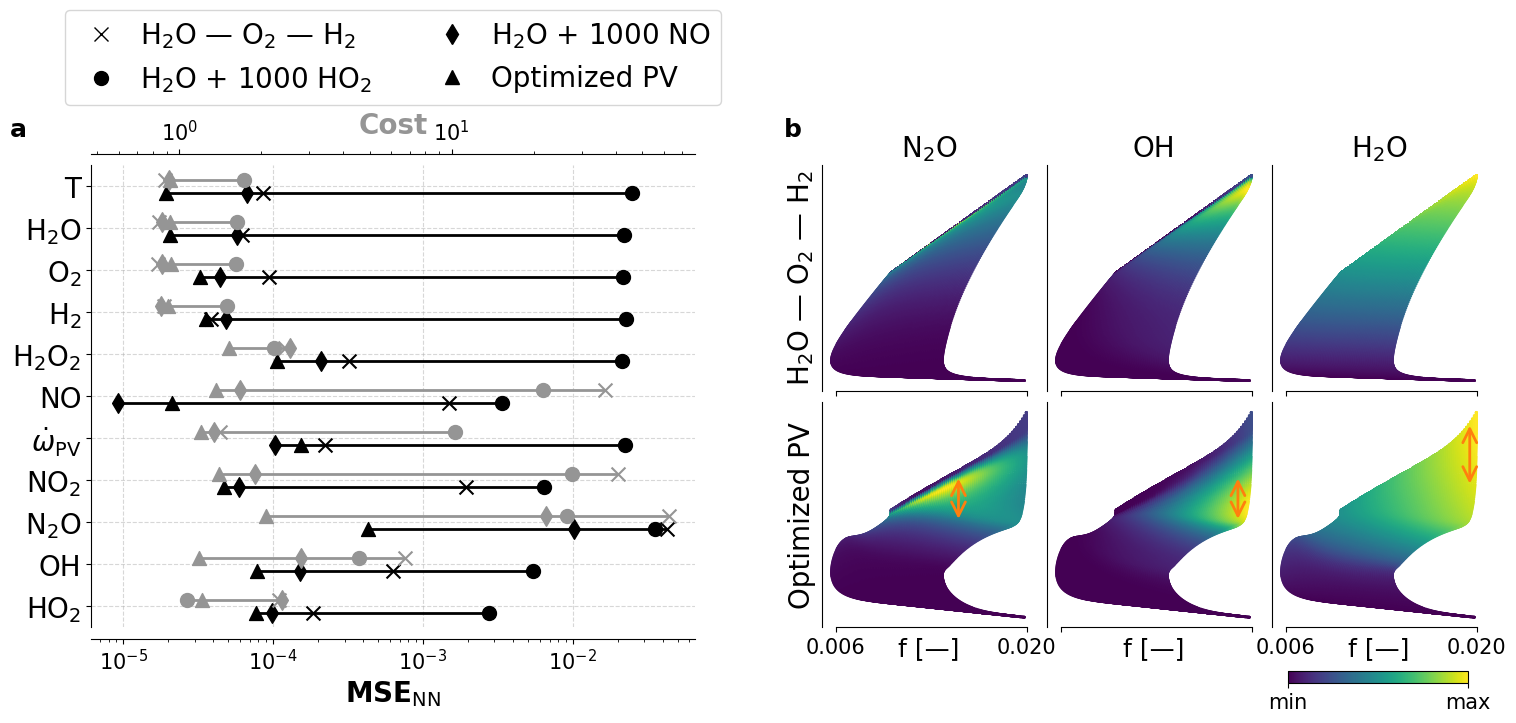

In [10]:
save = True
pathSave = f"C:/Users/Admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/Flamelet-Yuki/"
nameSave = f"Suppl. mat. - flamelet Yuki - heuristic vs. optimized PV - multi heu"

def add_panel_label(ax, label, x_offset=-0.12, y_offset=1.08, fontsize=18):
    ax.text(
        x_offset, y_offset,
        label,
        transform=ax.transAxes,
        fontsize=fontsize,
        fontweight="bold",
        va="top",
        ha="left",
        clip_on=False
    )

def plot_left_panel(ax_mse):
    greys = cm.get_cmap('Greys')

    ax_cost = ax_mse.twiny()

    for i, feature in enumerate(features_sorted):
        y_center = i

        # --- MSE ---
        y = y_center - subline_offset
        minMSE = np.min([MSE_heuristic_sorted[i], MSE_heuristicSoph1000HO2_sorted[i], MSE_heuristicSoph1000NO_sorted[i], MSE_Optimized_sorted[i]])
        maxMSE = np.max([MSE_heuristic_sorted[i], MSE_heuristicSoph1000HO2_sorted[i], MSE_heuristicSoph1000NO_sorted[i], MSE_Optimized_sorted[i]])
        ax_mse.plot([minMSE, maxMSE], [y, y], color="k", linewidth=2)

        ax_mse.scatter(MSE_heuristic_sorted[i], y, color="k", marker="x", s=100, zorder=4)
        ax_mse.scatter(MSE_heuristicSoph1000HO2_sorted[i], y, color="k", marker="o", s=100, zorder=4)
        ax_mse.scatter(MSE_heuristicSoph1000NO_sorted[i], y, color="k", marker="d", s=100, zorder=4)
        ax_mse.scatter(MSE_Optimized_sorted[i], y, color="k", marker="^", s=100, zorder=5)

        # --- Cost ---
        y = y_center + subline_offset
        minCost = np.min([Cost_heuristic_sorted[i], Cost_heuristicSoph1000HO2_sorted[i], Cost_heuristicSoph1000NO_sorted[i], Cost_Optimized_sorted[i]])
        maxCost = np.max([Cost_heuristic_sorted[i], Cost_heuristicSoph1000HO2_sorted[i], Cost_heuristicSoph1000NO_sorted[i], Cost_Optimized_sorted[i]])
        ax_cost.plot([minCost, maxCost], [y, y], color=greys(0.5), linewidth=2)

        ax_cost.scatter(Cost_heuristic_sorted[i], y, color=greys(0.5), marker="x", s=100)
        ax_cost.scatter(Cost_heuristicSoph1000HO2_sorted[i], y, color=greys(0.5), marker="o", s=100, zorder=1)
        ax_cost.scatter(Cost_heuristicSoph1000NO_sorted[i], y, color=greys(0.5), marker="d", s=100, zorder=1)
        ax_cost.scatter(Cost_Optimized_sorted[i], y, color=greys(0.5), marker="^", s=100)

    ax_mse.set_yticks(range(len(features_sorted)))
    ax_mse.set_yticklabels(features_sorted, fontsize=20)

    ax_mse.set_xlabel("MSE$_{\mathrm{NN}}$", fontsize=20, fontweight="bold")
    ax_cost.set_xlabel("Cost", fontsize=20, color=greys(0.5),
                       labelpad=-10, fontweight="bold")

    ax_mse.set_xscale("log")
    ax_cost.set_xscale("log")

    ax_mse.grid(axis='both', linestyle='--', alpha=0.5)
    ax_mse.tick_params(axis="x", labelsize=15)
    ax_cost.tick_params(axis="x", labelsize=15)

    ax_mse.set_ylim(-0.5, len(features_sorted) - 0.5)

    # Spines
    ax_mse.spines['top'].set_visible(False)
    ax_mse.spines['right'].set_visible(False)
    ax_cost.spines['right'].set_visible(False)
    ax_cost.spines['left'].set_visible(False)
    ax_cost.spines['bottom'].set_visible(False)

    offset = 8
    ax_mse.spines['bottom'].set_position(('outward', offset))
    ax_cost.spines['top'].set_position(('outward', offset))

    xmin, xmax = ax_cost.get_xlim()
    ax_cost.set_xlim(xmin - 0.2, xmax)

    # Legend (unchanged)
    legend_elements = [
        #Line2D([0], [0], color=greys(0.5), linestyle="-", lw=4, label="Cost"),
        #Line2D([0], [0], color="k", linestyle="-", lw=4, label="MSE$_{\mathrm{NN}}$"),
        Line2D([0], [0], color="k", marker="x", lw=0, markersize=10, label="H$_2$O \u2014 O$_2$ \u2014 H$_2$"),
        Line2D([0], [0], color="k", marker="o", lw=0, markersize=10, label="H$_2$O + 1000 HO$_2$"),
        Line2D([0], [0], color="k", marker="d", lw=0, markersize=10, label="H$_2$O + 1000 NO"),
        Line2D([0], [0], color="k", marker="^", lw=0, markersize=10, label="Optimized PV")
        ]
    ax_mse.legend(
                handles=legend_elements,
                fontsize=20,
                ncols=2,
                loc="lower center",
                bbox_to_anchor=(0.5, 1.1),
                handletextpad=0.5,
                handlelength=1.8
            )

def plot_right_panel(axes):
    rows, cols = axes.shape

    for idxKey, key in enumerate(keys):
        if key == "PV1":
            colorSpecies1 = PV_heuristic_source
            colorSpecies2 = PV_optimized_source
        else:
            colorSpecies1 = colorSpecies2 = x_fl[key]

        sc0 = axes[0, idxKey].scatter(
            mf_fl,
            PV_heuristic,
            c=colorSpecies1, cmap="viridis", s=1
        )

        sc1 = axes[1, idxKey].scatter(
            mf_fl,
            PV_optimized,
            c=colorSpecies2, cmap="viridis", s=1
        )

        
        axes[0, idxKey].set_yticks([])
        axes[1, idxKey].set_yticks([])

        axes[0, idxKey].set_title(nameCols[idxKey], fontsize=20)

        if(idxKey == 1):
            axes[1, idxKey].set_xlabel("f [\u2014]", fontsize = 18, labelpad = 0)
        else:
            axes[1, idxKey].set_xlabel("f [\u2014]", fontsize = 18, labelpad = -15)
        axes[0, idxKey].set_xticks([0.006, 0.020])
        axes[0, idxKey].set_xticklabels([])
        if(idxKey == 0):
            axes[1, idxKey].set_xticks([0.006, 0.020])
        elif(idxKey == 1):
            axes[1, idxKey].set_xticks([0.006, 0.020])
            axes[1, idxKey].set_xticklabels([])
        elif(idxKey == 2):
            axes[1, idxKey].set_xticks([0.006, 0.020])
        axes[1, idxKey].tick_params(axis = "x", labelsize = 15)


        if idxKey == 0:
            axes[0, idxKey].set_ylabel("H$_2$O \u2014 O$_2$ \u2014 H$_2$", fontsize=20)
            axes[1, idxKey].set_ylabel("Optimized PV", fontsize=20)

        x_arrows = [0.015, 0.019, 0.0195]

        # reference max value
        y_max = PV_optimized.max()

        # Bottom arrows (pointing upward)
        y_start_bottom = 0.05 * y_max
        y_end_bottom   = 0.25 * y_max

        # Top arrows (pointing downward)
        y_start_top = 0.85 * y_max
        y_end_top   = 0.65 * y_max

        arr_y_start_top = [0.6 * y_max, 0.6 * y_max, 0.9 * y_max]
        arr_y_end_top = [0.4 * y_max, 0.4 * y_max, 0.6 * y_max]

        margin = 0.02 * y_max

        for idxArrow, x in enumerate(x_arrows):
            # Bottom arrows
            if(idxKey == 1 and idxArrow == 1):
                axes[1, idxKey].annotate(
                    "",
                    xy=(x, arr_y_end_top[idxKey] - margin),
                    xytext=(x, arr_y_start_top[idxKey] + 2*margin),
                    arrowprops=dict(
                        arrowstyle="<->",
                        lw=2,
                        color="tab:orange",
                        mutation_scale=25
                    )
                )
            if(idxKey == 2 and idxArrow == 2):
                # Top arrows
                axes[1, idxKey].annotate(
                    "",
                    xy=(x, arr_y_end_top[idxKey] - margin),
                    xytext=(x, arr_y_start_top[idxKey] + 2*margin),
                    arrowprops=dict(
                        arrowstyle="<->",
                        lw=2,
                        color="tab:orange",
                        mutation_scale=25
                    )
                )
            if(idxKey == 0 and idxArrow == 0):
                # Top arrows
                axes[1,idxKey].annotate(
                    "",
                    xy=(x, arr_y_end_top[idxKey] - margin),
                    xytext=(x, arr_y_start_top[idxKey] + 2*margin),
                    arrowprops=dict(
                        arrowstyle="<->",
                        lw=2,
                        color="tab:orange",
                        mutation_scale=25
                    )
                )

    for ax in axes.flatten():
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_bounds(0.006, 0.020)

    return sc1

fig = plt.figure(figsize=(18, 6))

gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.1], hspace = 0.25)

ax_left = fig.add_subplot(gs[0, 0])

keys = ['N2O', 'OH', 'H2O']
nameCols = ['N$_2$O', 'OH', 'H$_2$O']
keysYaxis = [r"$Y_{NO}$"+ " [\u2014]", r"$Y_{H_2O_2}$"+ " [\u2014]",r"$\dot{\omega}_{\mathrm{PV}}$"+ " [1/s]"]

# Right panel needs a 2×N grid
subgs = gs[0, 1].subgridspec(2, len(keys), hspace=0.05, wspace=0.05)
axes_right = np.array([[fig.add_subplot(subgs[i, j]) for j in range(len(keys))]
                        for i in range(2)])

plot_left_panel(ax_left)
sc = plot_right_panel(axes_right)

# --- Add right panel colorbar ---
cax = fig.add_axes([0.79, 0.017, 0.1, 0.02])
cbar = fig.colorbar(sc, cax=cax, orientation='horizontal')
cbar.set_ticks([sc.get_array().min(), sc.get_array().max()])
cbar.set_ticklabels(["min", "max"])
cbar.ax.tick_params(labelsize=15)

plt.tight_layout()

fig.text(
    0.08, 0.96,  # x, y in figure coordinates (0..1)
    "a",
    fontsize=18,
    fontweight="bold",
    va="top",
    ha="left"
)

fig.text(
    0.51, 0.96,  # adjust to position over right panel
    "b",
    fontsize=18,
    fontweight="bold",
    va="top",
    ha="left"
)

if save:
    plt.savefig(pathSave + nameSave + ".png", dpi=1000, bbox_inches="tight")

plt.show()